In [15]:
import pandas as pd
from scipy import stats
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import os
import sys

In [17]:
banking_marketing_train_encoded = pd.read_csv('../data/processed/banking_marketing_train_processed.csv', delimiter=';', quotechar='"', encoding='utf-8')
banking_marketing_test_encoded = pd.read_csv('../data/processed/banking_marketing_test_processed.csv', delimiter=';', quotechar='"', encoding='utf-8')
banking_marketing_train_encoded_eda = pd.read_csv('../data/processed/banking_marketing_train_encoded_eda.csv', delimiter=';', quotechar='"', encoding='utf-8')

# KMeans clustering for customer segmentation

In [10]:
banking_marketing_train_clustered = banking_marketing_train_encoded
banking_marketing_test_clustered = banking_marketing_test_encoded

In [3]:
# Calculate the mean of each column in the DataFrame
mean_values = banking_marketing_train_encoded.mean()

# Print the mean values
print(mean_values)


age                   2.112250e-16
education             1.224813e+00
default               1.802659e-02
balance               1.760208e-17
housing               5.558382e-01
loan                  1.602265e-01
day                   1.257292e-17
month                 5.523014e+00
duration              6.035001e-17
campaign              3.017500e-17
pdays                 2.011667e-17
previous              4.023334e-17
y                     1.169848e-01
job_admin.            1.143748e-01
job_blue-collar       2.152573e-01
job_entrepreneur      3.289023e-02
job_housemaid         2.742695e-02
job_management        2.091969e-01
job_retired           5.007631e-02
job_self-employed     3.492513e-02
job_services          9.188029e-02
job_student           2.074716e-02
job_technician        1.680343e-01
job_unemployed        2.882042e-02
job_unknown           6.370131e-03
marital_divorced      1.151711e-01
marital_married       6.019332e-01
marital_single        2.828958e-01
contact_cellular    

/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_32429/2633759951.py:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  mean_values = banking_marketing_train_encoded.mean()


In [4]:
demographic_features = ['age', 'education','job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single']
financial_features = ['default', 'balance', 'housing', 'loan',]
behaviour_features = ['campaign','contact_cellular', 'contact_telephone', 'contact_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown', 'pdays', 'previous']
columns_for_clustering = demographic_features + financial_features + behaviour_features

# Extract the relevant columns
banking_marketing_train_clustered = banking_marketing_train_clustered[columns_for_clustering]
banking_marketing_test_clustered = banking_marketing_test_clustered[columns_for_clustering]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


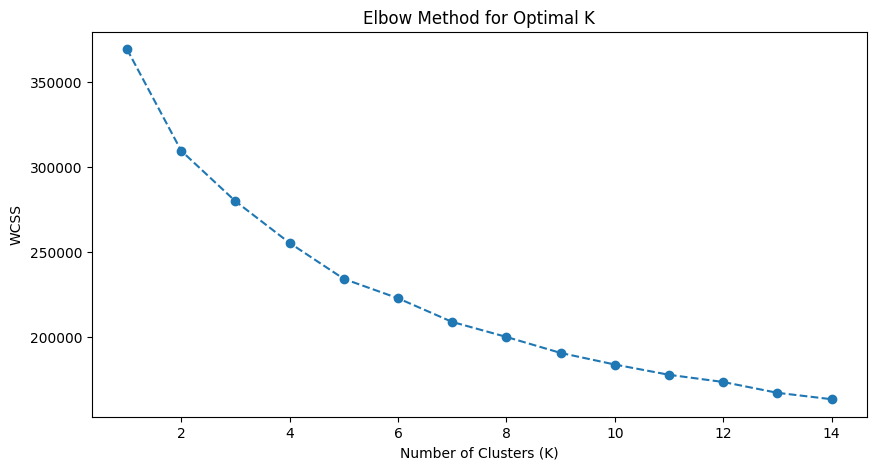

In [5]:
# Determine Optimal Number of Clusters 
wcss = []  # Within-cluster sum of squares
# silhouette_scores = []
K_range = range(1, 15)  # Start from 2 to avoid error with silhouette score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(banking_marketing_train_clustered)
    wcss.append(kmeans.inertia_)

    # Compute Silhouette Score
    # labels = kmeans.labels_
    # silhouette_scores.append(silhouette_score(banking_marketing_train_clustered, labels))

# Plot the elbow curve
plt.figure(figsize=(10,5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

# Plot Silhouette Scores
# plt.figure(figsize=(10,5))
# plt.plot(K_range, silhouette_scores, marker='o', linestyle='-', color='green')
# plt.xlabel("Number of Clusters (K)")
# plt.ylabel("Silhouette Score")
# plt.title("Silhouette Score for Optimal K")
# plt.show()

/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_32429/2622841834.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  banking_marketing_train_clustered['Cluster'] = kmeans.fit_predict(banking_marketing_train_clustered)
/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_32429/2622841834.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  banking_marketing_train_clustered['PCA1'] = pca_result[:, 0]
/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_32429/2622841834.py:17: SettingWit

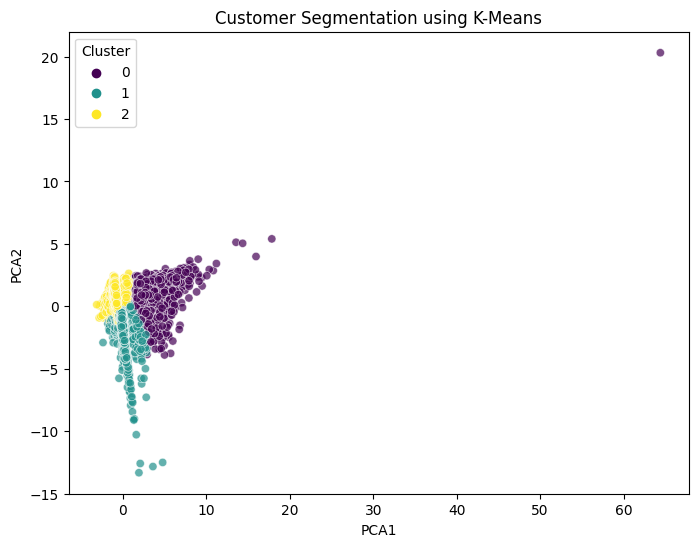

In [6]:
# apply kmeans
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
banking_marketing_train_clustered['Cluster'] = kmeans.fit_predict(banking_marketing_train_clustered)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(banking_marketing_train_clustered)

# Create DataFrame for PCA components with sorted contributions
# pca_df = pd.DataFrame(pca.components_, columns=banking_marketing_train_encoded.drop(columns = ['Cluster']).columns, index=['PCA1', 'PCA2'])

# Sort by the contributions to PCA1
# print(pca_df.T.sort_values(by="PCA1", ascending=False))

banking_marketing_train_clustered['PCA1'] = pca_result[:, 0]
banking_marketing_train_clustered['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(x=banking_marketing_train_clustered['PCA1'], y=banking_marketing_train_clustered['PCA2'], hue=banking_marketing_train_clustered['Cluster'], palette='viridis', alpha = 0.7)
plt.title("Customer Segmentation using K-Means")
plt.show()


In [7]:
# Analyze Cluster Characteristics
cluster_summary = banking_marketing_train_clustered.groupby('Cluster').mean()

In [8]:
# Print each row of the summary
for index, row in cluster_summary.iterrows():
    print(f"Cluster {index}:")
    print(row)
    print("\n")


Cluster 0:
age                 -0.111366
education            1.262672
job_admin.           0.136448
job_blue-collar      0.217947
job_entrepreneur     0.028965
job_housemaid        0.015618
job_management       0.216953
job_retired          0.029107
job_self-employed    0.035496
job_services         0.093994
job_student          0.030811
job_technician       0.166406
job_unemployed       0.024847
job_unknown          0.003408
marital_divorced     0.114298
marital_married      0.572057
marital_single       0.313645
default              0.007809
balance              0.025685
housing              0.690899
loan                 0.147096
campaign            -0.217366
contact_cellular     0.925316
contact_telephone    0.065881
contact_unknown      0.008803
poutcome_failure     0.638080
poutcome_other       0.219509
poutcome_success     0.141843
poutcome_unknown     0.000568
pdays                2.069976
previous             1.227506
PCA1                 2.885674
PCA2                 0.520381

In [9]:
banking_marketing_train_clustered_with_y = banking_marketing_train_clustered
banking_marketing_train_clustered_with_y['y'] = banking_marketing_train_encoded['y']

/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_32429/645723935.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  banking_marketing_train_clustered_with_y['y'] = banking_marketing_train_encoded['y']


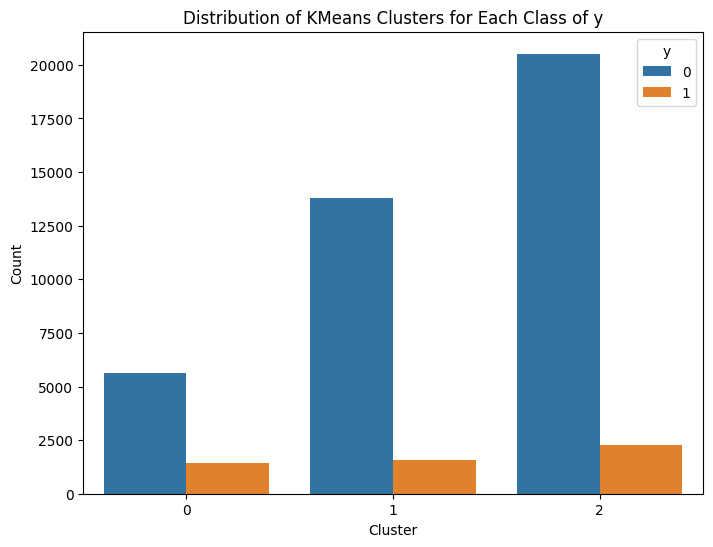

In [10]:
# Assuming 'Cluster' column is in your dataframe with KMeans results
plt.figure(figsize=(8, 6))
sns.countplot(x='Cluster', hue='y', data=banking_marketing_train_clustered_with_y)
plt.title("Distribution of KMeans Clusters for Each Class of y")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


In [11]:
# Group the data by 'Cluster' and calculate the ratio of 1s in each cluster
cluster_ratios = banking_marketing_train_clustered_with_y.groupby('Cluster')['y'].mean()

# Find the cluster with the highest ratio of 1s
max_cluster = cluster_ratios.idxmax()
max_ratio = cluster_ratios.max()

# Print the result
print(f"Cluster {max_cluster} has the highest ratio of 1s with a ratio of {max_ratio:.4f}")


Cluster 0 has the highest ratio of 1s with a ratio of 0.2028


### Cluster Analysis

Cluster 0: Appears to be a relatively stable group with moderate campaign participation and high financial balances. The higher cellular contact rate suggests good engagement with marketing efforts, though the failure rate is still significant.   -> higher success rate

Cluster 1: Represents a more industrial, blue-collar group with lower balances and more focused telephone contact. This group has a high unknown outcome in campaigns, suggesting low engagement or response.

Cluster 2: Features a balanced mix of job categories and high campaign participation, with 100% cellular contact indicating a more modern, tech-savvy group. This cluster is most likely to have responses marked as unknown in past campaigns.

## Validate Data Distribution With Test Data

In [12]:
banking_marketing_test_clustered.columns

Index(['age', 'education', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'default', 'balance', 'housing', 'loan', 'campaign', 'contact_cellular',
       'contact_telephone', 'contact_unknown', 'poutcome_failure',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'pdays',
       'previous'],
      dtype='object')

### use kmeans.predict

In [13]:
# Assuming 'kmeans' is the trained K-Means model from your training set
predicted_clusters = kmeans.predict(banking_marketing_test_clustered)

# Add the predicted clusters to the test data
banking_marketing_test_clustered['cluster'] = predicted_clusters


/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_32429/3850714663.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  banking_marketing_test_clustered['cluster'] = predicted_clusters


Compare the Ratio

In [15]:
banking_marketing_test_clustered['y'] = banking_marketing_test_encoded['y']

/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_32429/84447885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  banking_marketing_test_clustered['y'] = banking_marketing_test_encoded['y']


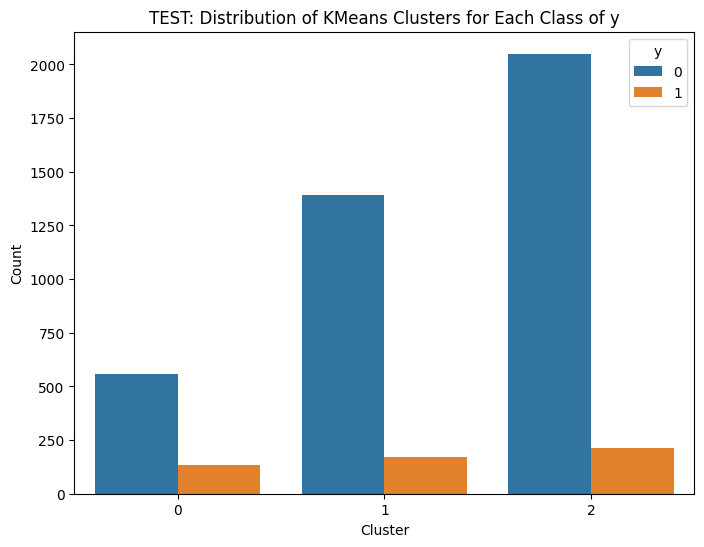

In [17]:
# plot
plt.figure(figsize=(8, 6))
sns.countplot(x='cluster', hue='y', data=banking_marketing_test_clustered)
plt.title("TEST: Distribution of KMeans Clusters for Each Class of y")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


In [18]:
# Group the data by 'Cluster' and calculate the ratio of 1s in each cluster
cluster_ratios = banking_marketing_test_clustered.groupby('cluster')['y'].mean()

# Find the cluster with the highest ratio of 1s
max_cluster = cluster_ratios.idxmax()
max_ratio = cluster_ratios.max()

# Print the result
print(f"Cluster {max_cluster} has the highest ratio of 1s with a ratio of {max_ratio:.4f}")


Cluster 0 has the highest ratio of 1s with a ratio of 0.1965


In [19]:
banking_marketing_test_clustered['cluster'].value_counts(normalize=True)

2    0.500995
1    0.345941
0    0.153063
Name: cluster, dtype: float64

In [20]:
test_summary = banking_marketing_test_clustered.groupby('cluster').mean()

In [21]:
# Print each row of the summary
for index, row in test_summary.iterrows():
    print(f"Cluster {index}:")
    print(row)
    print("\n")

Cluster 0:
age                 -0.086670
education            1.280347
job_admin.           0.130058
job_blue-collar      0.210983
job_entrepreneur     0.030347
job_housemaid        0.015896
job_management       0.231214
job_retired          0.026012
job_self-employed    0.034682
job_services         0.082370
job_student          0.024566
job_technician       0.183526
job_unemployed       0.024566
job_unknown          0.005780
marital_divorced     0.105491
marital_married      0.596821
marital_single       0.297688
default              0.007225
balance              0.069432
housing              0.710983
loan                 0.135838
campaign            -0.227902
contact_cellular     0.914740
contact_telephone    0.072254
contact_unknown      0.013006
poutcome_failure     0.634393
poutcome_other       0.238439
poutcome_success     0.127168
poutcome_unknown     0.000000
pdays                2.075200
previous             1.147088
y                    0.196532
Name: 0, dtype: float64


Clu

### Conclustion:

Financial stability is the most important feature for deciding high-value group, and they should be priotised
Cluster 0 customers are generally wealthier, with higher average balances and a greater likelihood of having housing loans compared to the general population. They are slightly younger and tend to be more responsive to cellular contact, though they have a higher proportion of failed outcomes and fewer responses to campaigns. These customers also have a more persistent history of contact with the bank, as indicated by higher numbers of previous contacts and longer gaps between interactions. While their job and marital status distributions are fairly similar to the broader population, Cluster 0 shows a slight tendency toward a higher proportion of single individuals.

The test cluster 0 shows higher average balances (1639.67 vs. 1557.00) and a lower loan rate (12.13% vs. 13.59%) compared to the training cluster, suggesting a more affluent group. Both clusters exhibit similar job and marital status distributions, with strong engagement through cellular contact. However, the test cluster has a slightly higher campaign success rate (22.55% vs. 18.31%) and is less similar to the high-value segment, as indicated by a higher distance (5.93 vs. 3.61) and lower similarity (0.56 vs. 0.57).


# Marketing Strategy Optimization: Multi-Armed Bandit, Reinforcement Learning, AB Test

In [31]:
banking_marketing_train_rl = banking_marketing_train_encoded
banking_marketing_test_rl = banking_marketing_test_encoded

In [32]:
banking_marketing_train_rl.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown', 'deposit_amount', 'term', 'interest_rate',
       'conversion_binary', 'conversion_rate', 'best_contact_time',
       'decay_factor', 'fatigue_score', 'cost', 'job', 'marital', 'contact',
       'poutcome', 'purchase_frequency', 'revenue', 'customer_lifespan', 'CLV',
       'new_customer', 'CAC', 'ROI'],
      dtype='object')

In [33]:
# remove columns with string
columns_to_drop_for_rl = ['best_contact_time'] 
banking_marketing_train_rl = banking_marketing_train_rl.drop(columns = columns_to_drop_for_rl)
banking_marketing_test_rl = banking_marketing_test_rl.drop(columns = columns_to_drop_for_rl)


In [34]:
# define
xtrain = banking_marketing_train_rl.drop(columns=['y'])
ytrain = banking_marketing_train_rl['y'].values
xtest = banking_marketing_test_rl.drop(columns=['y'])
ytest = banking_marketing_test_rl['y'].values

## Multi-Armed Bandit: UCB1 - general exploration

Cost Calculation:

Broad: 1
Group-Based: 0.18*3+0.34*1+0.48*2 = 1.84    (segment clients into 3 groups and apply different personalisation levels on each group)
AI-Based: 3

From clustering of test data: 
2    0.478655   - medium-value 
1    0.340854   - low-value (extent of personalisation has uncertain effect)
0    0.180491   - high-value

In [35]:
np.random.seed(42)

class UCB1:
    def __init__(self, n_strategies):
        self.n = n_strategies  # Number of marketing strategies
        self.counts = np.zeros(n_strategies)  # Number of times each strategy is chosen
        self.values = np.zeros(n_strategies)  # Expected reward for each strategy

    def select_strategy(self):
        """Select strategy using UCB1 formula."""
        total_counts = sum(self.counts)
        if 0 in self.counts:
            return np.argmin(self.counts)  # Explore untested strategies

        ucb_values = self.values + np.sqrt(2 * np.log(total_counts) / self.counts)
        return np.argmax(ucb_values)  # Select the strategy with highest UCB score

    def update(self, chosen_strategy, reward, cost):
        """Update strategy reward estimates considering both reward and cost."""
        # Calculate the net reward (reward - cost)
        net_reward = reward - cost
        self.counts[chosen_strategy] += 1
        # Update the value estimate using the net reward (reward - cost)
        self.values[chosen_strategy] += (net_reward - self.values[chosen_strategy]) / self.counts[chosen_strategy]

# Initialize UCB1 for 3 strategies
ucb_agent = UCB1(n_strategies=3)

# Define cost for each strategy (e.g., personalization costs)
costs = [1, 1.84, 3]  # Example costs for strategies: Broad, Group-Based, AI-Based

# Simulate 1000 campaigns
for t in range(1000):
    strategy = ucb_agent.select_strategy()  # Choose best strategy
    # Simulate reward (could be based on conversion, retention, etc.)
    reward = np.random.uniform(0, 100)  # Simulated reward (random for example)
    cost = costs[strategy]  # Cost for the chosen strategy
    ucb_agent.update(strategy, reward, cost)

print("Final expected values:", ucb_agent.values)


Final expected values: [36.45401188 40.42871251 46.20384843]


## Reinforcement Learning: DQN - find optimal strategy

We treat the marketing campaign as a Markov Decision Process (MDP):

State (S): Customer features (age, job, marital status, etc.).
Actions (A): Which marketing strategy to use.
Reward (R): 1 if the customer subscribes, 0 otherwise.
Q-value (Q(S, A)): Expected success rate of using strategy A in state S.
We train a Deep Q-Network (DQN) to approximate Q(S, A) and select the best strategy.

In [36]:
# Target variable (no need to standardize)
target = ['y']

# Hyperparameters
STATE_SIZE = xtrain.shape[1]
ACTION_SIZE = 3  # Broad, Group-Based, AI-Based
GAMMA = 0.95  # Discount Factor
LR = 0.001  # Learning Rate
EPSILON = 1.0  # Initial exploration
EPSILON_DECAY = 0.98  # Smoother decay
EPSILON_MIN = 0.01
MEMORY_SIZE = 5000  # Increased memory for better experience replay
BATCH_SIZE = 64  # Larger batch size for stability

# Define Q-Network
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Experience Replay Memory
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def add(self, experience):
        self.memory.append(experience)

    def sample(self, batch_size):
        return random.sample(self.memory, min(batch_size, len(self.memory)))

# Q-Learning Agent
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = ReplayMemory(MEMORY_SIZE)
        self.epsilon = EPSILON  # Exploration rate
        self.model = DQN(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=LR)
        self.loss_fn = nn.MSELoss()

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return random.randrange(self.action_size)
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            return torch.argmax(self.model(state_tensor)).item()

    def train(self):
        if len(self.memory.memory) < BATCH_SIZE:
            return

        batch = self.memory.sample(BATCH_SIZE)
        states, actions, rewards, next_states = zip(*batch)

        states_tensor = torch.FloatTensor(states)
        # states_array = np.array(states, dtype=np.float32)  # Ensure it's a NumPy array of floats
        # states_tensor = torch.tensor(states_array)  # Convert to tensor
        actions_tensor = torch.LongTensor(actions).unsqueeze(1)
        rewards_tensor = torch.FloatTensor(rewards)
        next_states_tensor = torch.FloatTensor(next_states)

        q_values = self.model(states_tensor).gather(1, actions_tensor).squeeze()
        next_q_values = self.model(next_states_tensor).max(1)[0].detach()
        target_q_values = rewards_tensor + GAMMA * next_q_values

        loss = self.loss_fn(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_epsilon(self):
        self.epsilon = max(EPSILON_MIN, self.epsilon * EPSILON_DECAY)

# Reward function
def calculate_reward(conversion, cost, retention_rate, clv, budget_left):
    profit = conversion * clv
    penalty = 0.2 * cost  # Reduced penalty to balance strategy
    budget_penalty = -10 if budget_left < 0 else 0
    return profit - penalty + (0.7 * retention_rate) + budget_penalty

# Extract state representation
def get_state(customer):
    return np.array(customer).flatten()

# Strategy-based retention rate
def calculate_strategy_based_retention_rate(action):
    return [np.random.uniform(0.2, 0.4), np.random.uniform(0.4, 0.6), np.random.uniform(0.6, 0.8)][action]

# Define strategies and costs
strategies = {0: 'Broad', 1: 'Group-Based', 2: 'AI-Based'} # Broad, Group-Based, AI-Based
retention_rates = {0: 0.3, 1: 0.6, 2: 0.9}
campaign_rewards = {0: 50, 1: 55, 2: 60}

# initiate agent
agent = DQNAgent(STATE_SIZE, ACTION_SIZE)

num_campaigns = 10
total_rewards = {0: 0, 1: 0, 2: 0}
epsilon = 1.0  # Start with high exploration

for campaign in range(num_campaigns):
    print(f"\n🔹 Running Campaign {campaign + 1}...")

    # input budget amount
    ###
    budget = 10000 
    ###

    indices = np.arange(len(xtrain))
    np.random.shuffle(indices)  # Shuffle training order

    for idx in indices:
        customer = xtrain.iloc[idx]
        state = get_state(customer)

        action = agent.select_action(state) if np.random.rand() > epsilon else np.random.choice(list(strategies.keys()))
        
        # cost = costs[action]
        cost = customer['cost']
        retention_rate = calculate_strategy_based_retention_rate(action)

        conversion = ytrain[idx]
        clv = customer['CLV'] if conversion else 0 # CLV column

        reward = calculate_reward(conversion, cost, retention_rate, clv, budget)
        budget -= cost

        # Stop if budget is exhausted
        if budget <= 0:
            break

        next_state = get_state(xtrain.iloc[np.random.randint(len(xtrain))])  # Random next state
        agent.memory.add((state, action, reward, next_state))
        agent.train()

        # Update total rewards: Accumulate the individual reward - cost for each customer interaction
        total_rewards[action] += reward

    # Reduce epsilon (less exploration over time)
    epsilon = max(epsilon * EPSILON_DECAY, EPSILON_MIN)

# Select best strategy
best_strategy = max(total_rewards, key=total_rewards.get)
print('\nTRAIN RESULT:')
print(f"✅ Final Recommended Strategy after {num_campaigns} campaigns: {strategies[best_strategy]}")



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🔹 Running Campaign 1...


/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_32429/2811753765.py:64: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  states_tensor = torch.FloatTensor(states)



🔹 Running Campaign 2...

🔹 Running Campaign 3...

🔹 Running Campaign 4...

🔹 Running Campaign 5...

🔹 Running Campaign 6...

🔹 Running Campaign 7...

🔹 Running Campaign 8...

🔹 Running Campaign 9...

🔹 Running Campaign 10...

TRAIN RESULT:
✅ Final Recommended Strategy after 10 campaigns: Group-Based


In [37]:
# Prepare for evaluation
test_rewards = {0: 0, 1: 0, 2: 0}  # Track total rewards for each strategy

# Run evaluation on test data
for idx in range(len(xtest)):  # Iterate over the test data
    customer = xtest.iloc[idx]  # Get customer data from the test set
    state = get_state(customer)  # Extract the state representation

    # **Use the trained model to select the best action**
    action = agent.select_action(state)  # Exploit the learned policy

    # Get cost, retention rate, and other necessary info for the selected action
    # cost = costs[action]
    cost = customer['cost']
    retention_rate = retention_rates[action]

    # Get actual conversion rate from ytest
    conversion = ytest[idx]  # Test data labels (converted or not)
    clv = customer['CLV'] if conversion else 0 # CLV column

    # Calculate reward based on conversion, cost, retention, and CLV
    reward = calculate_reward(conversion, cost, retention_rate, clv, budget_left=0)  # Assuming no budget for simplicity
    test_rewards[action] += reward  # Accumulate rewards for each strategy

# Print the final evaluation metrics
print("\n Evaluation on Test Data:")
for action in strategies.keys():
    print(f"Strategy {strategies[action]}: Total Reward = {test_rewards[action]}")

# Optionally, you can calculate and print the average reward across all strategies
total_test_reward = sum(test_rewards.values())
avg_test_reward = total_test_reward / len(test_rewards)

print(f"Average Reward across all strategies: {avg_test_reward}")

# Select best strategy
best_strategy = max(test_rewards, key=test_rewards.get)
print(f"\n✅ Final Recommended Strategy: {strategies[best_strategy]}")



 Evaluation on Test Data:
Strategy Broad: Total Reward = 817699794540.3693
Strategy Group-Based: Total Reward = 874309533890.7272
Strategy AI-Based: Total Reward = 712084804163.027
Average Reward across all strategies: 801364710864.7079

✅ Final Recommended Strategy: Group-Based


# AB testing

In [ ]:
# import data that is not standardised
banking_marketing_train_ab = banking_marketing_train_encoded_eda


In [45]:
# Step 2: Separate the groups (contacted vs. not contacted)
treatment_group = banking_marketing_train_ab[banking_marketing_train_ab['pdays'] != -1]['y']  # Customers contacted
control_group = banking_marketing_train_ab[banking_marketing_train_ab['pdays'] == -1]['y']   # Customers not contacted

# Step 3: Calculate subscription rates (proportions)
subscription_rate_treatment = treatment_group.mean()
subscription_rate_control = control_group.mean()

print(f"Subscription rate for contacted customers: {subscription_rate_treatment:.2f}")
print(f"Subscription rate for non-contacted customers: {subscription_rate_control:.2f}")

# Step 4: Perform a proportion test (z-test) to compare the subscription rates
# Proportion test requires the observed number of successes (subscribed) and failures (not subscribed) in both groups.
success_treatment = treatment_group.sum()
failure_treatment = len(treatment_group) - success_treatment

success_control = control_group.sum()
failure_control = len(control_group) - success_control

# Combine the groups for z-test
n_treatment = len(treatment_group)
n_control = len(control_group)

# p1: proportion of successes in treatment group
p1 = success_treatment / n_treatment
# p2: proportion of successes in control group
p2 = success_control / n_control

# p_pool: pooled proportion (pooled success rate across both groups)
p_pool = (success_treatment + success_control) / (n_treatment + n_control)

# Standard error of the difference between proportions
se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_treatment + 1 / n_control))

# Z-statistic for testing the difference in proportions
z_stat = (p1 - p2) / se

# Two-tailed p-value from the z-statistic
p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))

# Step 5: Output the results
print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Step 6: Conclusion based on the p-value
if p_value < 0.05:
    print("There is a significant difference in subscription rates between contacted and non-contacted customers.")
else:
    print("There is no significant difference in subscription rates between contacted and non-contacted customers.")


Subscription rate for contacted customers: 0.23
Subscription rate for non-contacted customers: 0.09
Z-statistic: 35.565
P-value: 0.000
There is a significant difference in subscription rates between contacted and non-contacted customers.
